# 3-D segmentation — train / val / test

Processes the full `(H, D, W)` volume with a **3-D DynUNet**.  
Training samples random `PATCH_SIZE` crops biased toward foreground (clasts are only ~2 % of voxels).  
Split is a contiguous slice range along the H axis so every 3-D patch drawn during training is self-consistent.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import monai
import nibabel as nib
from monai.data import DataLoader, Dataset
from monai.inferers import sliding_window_inference
from pathlib import Path
from monai.networks.nets import DynUNet
from scipy.ndimage import binary_dilation
from time import perf_counter as time

## 1. Data

In [2]:
IMAGE_NII = Path("/zhome/d8/d/230907/me/meteorite/data/xray_2.nii")
SEG_NII   = Path("/zhome/d8/d/230907/me/meteorite/masks/ROI_total.nii.gz")

img_vol = nib.load(IMAGE_NII).get_fdata().astype(np.float32)
seg_vol = nib.load(SEG_NII).get_fdata()

img_vol    = (img_vol - img_vol.min()) / (img_vol.max() - img_vol.min())
binary_seg = np.isin(seg_vol, [1, 2, 3]).astype(np.float32)
roi_mask   = binary_dilation(seg_vol != 0, iterations=0).astype(np.float32)

print(f'Volume shape : {img_vol.shape}   (H, D, W)')
print(f'Foreground   : {binary_seg.mean()*100:.2f}%')

Volume shape : (944, 180, 725)   (H, D, W)
Foreground   : 2.29%


## 2. Train / Val / Test split

Contiguous H-axis ranges so that 3-D patches sampled during training never straddle a split boundary.

In [3]:
GOOD_START = 101
GOOD_END   = 840
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

n_good      = GOOD_END - GOOD_START
train_end   = GOOD_START + int(n_good * TRAIN_FRAC)
val_end     = train_end  + int(n_good * VAL_FRAC)
test_end    = GOOD_END

# Ensure all dims divisible by 8 for the UNet encoder strides
# D (180) and W (725) are handled by DivisiblePadd; H ranges are controlled here

def make_vol(h_start, h_end):
    return {
        'image': img_vol[h_start:h_end, :, :][None],      # (1, H, D, W)
        'label': binary_seg[h_start:h_end, :, :][None],
        'roi':   roi_mask[h_start:h_end, :, :][None],
    }

train_vol = make_vol(GOOD_START, train_end)
val_vol   = make_vol(train_end,  val_end)
test_vol  = make_vol(val_end,    test_end)

print(f'Train H: {GOOD_START}–{train_end}  ({train_end-GOOD_START} slices)  shape: {train_vol["image"].shape}')
print(f'Val   H: {train_end}–{val_end}    ({val_end-train_end} slices)  shape: {val_vol["image"].shape}')
print(f'Test  H: {val_end}–{test_end}    ({test_end-val_end} slices)  shape: {test_vol["image"].shape}')

Train H: 101–618  (517 slices)  shape: (1, 517, 180, 725)
Val   H: 618–728    (110 slices)  shape: (1, 110, 180, 725)
Test  H: 728–840    (112 slices)  shape: (1, 112, 180, 725)


## 3. Transforms

`RandCropByPosNegLabeld` samples patches biased toward foreground (`pos=2, neg=1`).  
The training volume is repeated `REPEAT` times so each epoch sees many independent random crops.

In [4]:
PATCH_SIZE = (128, 128, 128)
REPEAT     = 50   # copies of the training volume per epoch → 200 random crops per epoch

train_transforms = monai.transforms.Compose([
    monai.transforms.ScaleIntensityd(keys=['image']),
    monai.transforms.RandCropByPosNegLabeld(
        keys=['image', 'label', 'roi'],
        label_key='label',
        spatial_size=PATCH_SIZE,
        pos=2, neg=1,
        num_samples=1,
    ),
    monai.transforms.RandFlipd(keys=['image', 'label', 'roi'], prob=0.5, spatial_axis=0),
    monai.transforms.RandFlipd(keys=['image', 'label', 'roi'], prob=0.5, spatial_axis=1),
    monai.transforms.RandFlipd(keys=['image', 'label', 'roi'], prob=0.5, spatial_axis=2),
    monai.transforms.RandGaussianNoised(keys=['image'], prob=0.2, mean=0.0, std=0.02),
])

val_transforms = monai.transforms.Compose([
    monai.transforms.ScaleIntensityd(keys=['image']),
])

train_files = [train_vol] * REPEAT
val_files   = [val_vol]
test_files  = [test_vol]

## 4. Model

In [5]:
model = DynUNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    kernel_size=[3, 3, 3, 3],
    strides=[1, 2, 2, 2],
    upsample_kernel_size=[2, 2, 2],
    dropout=0.2,
)

loss_fn   = monai.losses.DiceCELoss(sigmoid=True, lambda_dice=1.0, lambda_ce=0.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params/1e6:.2f}M')

Trainable parameters: 5.60M


In [6]:
USE_MODEL_CHECKPOINT = False
checkpoint_file = "/zhome/d8/d/230907/me/meteorite/weights/model_3d_real.pth"

if USE_MODEL_CHECKPOINT:
    checkpoint = torch.load(checkpoint_file)
    model.load_state_dict(checkpoint['model'])

## 5. Training

In [7]:
NUM_EPOCHS = 50
BATCH_SIZE = 4

train_loader = DataLoader(
    Dataset(data=train_files, transform=train_transforms),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True,
)
val_loader = DataLoader(
    Dataset(data=val_files, transform=val_transforms),
    batch_size=1, shuffle=False,
)

model     = model.cuda()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

if USE_MODEL_CHECKPOINT:
    all_train_losses = checkpoint['train_losses']
    all_val_losses   = checkpoint['val_losses']
    best_val_loss    = min(checkpoint['val_losses'])
else:
    all_train_losses, all_val_losses = [], []
    best_val_loss = float('inf')

t0 = time()
for epoch in range(NUM_EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    epoch_loss, steps = 0, 0
    for batch in train_loader:
        inputs  = batch['image'].cuda(non_blocking=True)
        targets = batch['label'].cuda(non_blocking=True).float()
        roi     = batch['roi'].cuda(non_blocking=True)
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = torch.where(roi.expand_as(outputs) > 0, outputs, torch.full_like(outputs, -20.0))
        loss    = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.detach(); steps += 1
    train_loss = epoch_loss.item() / steps
    all_train_losses.append(train_loss)
    scheduler.step()

    # ── Validation (sliding window on the val sub-volume) ──────────────────
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            inp  = batch['image'].cuda(non_blocking=True)
            tgt  = batch['label'].cuda(non_blocking=True).float()
            roi  = batch['roi'].cuda(non_blocking=True)
            logits = sliding_window_inference(
                inp, PATCH_SIZE, sw_batch_size=4, predictor=model, overlap=0.25,
            )
            logits = torch.where(roi.expand_as(logits) > 0, logits, torch.full_like(logits, -20.0))
            val_loss = loss_fn(logits, tgt).item()
    all_val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
            'epoch': epoch, 'train_losses': all_train_losses, 'val_losses': all_val_losses,
        }, checkpoint_file)
        print(f'  -> Saved (val {val_loss:.4f})')
    print(f'Epoch {epoch+1:3d}  train={train_loss:.4f}  val={val_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}  [{time()-t0:.0f}s]')

/dtu/3d-imaging-center/courses/02510/groups/killian/gpu_env/lib/python3.11/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/dtu/3d-imaging-center/courses/02510/groups/killian/gpu_env/lib/python3.11/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different res

  -> Saved (val 0.9023)
Epoch   1  train=0.9049  val=0.9023  lr=9.99e-04  [34s]
  -> Saved (val 0.8978)
Epoch   2  train=0.8983  val=0.8978  lr=9.96e-04  [65s]
Epoch   3  train=0.8651  val=0.9190  lr=9.91e-04  [96s]
  -> Saved (val 0.8865)
Epoch   4  train=0.8148  val=0.8865  lr=9.84e-04  [126s]
  -> Saved (val 0.8345)
Epoch   5  train=0.8086  val=0.8345  lr=9.76e-04  [157s]
  -> Saved (val 0.7544)
Epoch   6  train=0.7916  val=0.7544  lr=9.65e-04  [189s]
  -> Saved (val 0.7429)
Epoch   7  train=0.7413  val=0.7429  lr=9.52e-04  [222s]
  -> Saved (val 0.6671)
Epoch   8  train=0.7179  val=0.6671  lr=9.38e-04  [256s]
  -> Saved (val 0.6476)
Epoch   9  train=0.6982  val=0.6476  lr=9.22e-04  [290s]
  -> Saved (val 0.6437)
Epoch  10  train=0.7330  val=0.6437  lr=9.05e-04  [325s]
Epoch  11  train=0.7164  val=0.7393  lr=8.85e-04  [358s]
  -> Saved (val 0.6094)
Epoch  12  train=0.6786  val=0.6094  lr=8.64e-04  [390s]
  -> Saved (val 0.5873)
Epoch  13  train=0.7079  val=0.5873  lr=8.42e-04  [423s

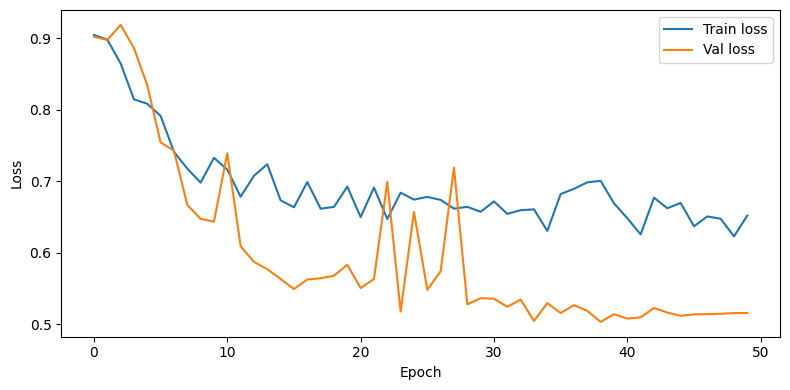

Best val loss: 0.5035 at epoch 39


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(all_train_losses, label='Train loss')
ax.plot(all_val_losses,   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Best val loss: {min(all_val_losses):.4f} at epoch {np.argmin(all_val_losses)+1}')

## 6. Evaluation on test set

In [9]:
checkpoint = torch.load(checkpoint_file)
model.load_state_dict(checkpoint['model'])
model.eval()

test_loader = DataLoader(
    Dataset(data=test_files, transform=val_transforms),
    batch_size=1, shuffle=False,
)

all_tp, all_fp, all_fn = 0, 0, 0
with torch.no_grad():
    for batch in test_loader:
        inp = batch['image'].cuda(non_blocking=True)
        tgt = batch['label'].cuda(non_blocking=True).float()
        roi = batch['roi'].cuda(non_blocking=True)
        logits = sliding_window_inference(
            inp, PATCH_SIZE, sw_batch_size=4, predictor=model, overlap=0.25,
        )
        logits = torch.where(roi.expand_as(logits) > 0, logits, torch.full_like(logits, -20.0))
        pred    = (torch.sigmoid(logits) > 0.5).float()
        all_tp += (pred * tgt).sum().item()
        all_fp += (pred * (1 - tgt)).sum().item()
        all_fn += ((1 - pred) * tgt).sum().item()

test_dice = 2*all_tp / (2*all_tp + all_fp + all_fn + 1e-8)
print(f'Test Dice : {test_dice:.4f}')
print(f'Best epoch: {checkpoint["epoch"]+1}  (val loss {min(all_val_losses):.4f})')

Test Dice : 0.4200
Best epoch: 39  (val loss 0.5035)


## 7. Visualization

Run inference on the full volume then inspect axial slices with a slider.

In [10]:
model.eval()

full_inp = torch.from_numpy(img_vol[None, None]).float().cuda()  # (1, 1, H, D, W)

with torch.no_grad():
    full_logits = sliding_window_inference(
        full_inp, PATCH_SIZE, sw_batch_size=4, predictor=model, overlap=0.25,
    )

pred_vol = (torch.sigmoid(full_logits).squeeze().cpu().numpy()  # (H, D, W)
            * roi_mask)                                           # zero outside ROI
print(f'pred_vol shape: {pred_vol.shape}')

pred_vol shape: (944, 180, 725)


In [ ]:
import ipywidgets as widgets

def show(h):
    img   = img_vol[h, :, :]
    gt    = binary_seg[h, :, :]
    probs = pred_vol[h, :, :]
    pred  = probs > 0.5

    fn_mask = (gt == 1) & (pred == 0)
    tp_mask = (gt == 1) & (pred == 1)
    fp_mask = (gt == 0) & (pred == 1)

    split = ('TRAIN' if GOOD_START <= h < train_end
             else 'VAL' if train_end <= h < val_end
             else 'TEST' if val_end <= h < test_end
             else 'outside')

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'H={h}  [{split}]'); axes[0].axis('off')

    axes[1].imshow(img, cmap='gray')
    axes[1].imshow(np.where(fn_mask, 1, np.nan), cmap='Greens', alpha=0.9, vmin=0, vmax=1)
    axes[1].imshow(np.where(tp_mask, 1, np.nan), cmap='Blues',  alpha=0.9, vmin=0, vmax=1)
    axes[1].imshow(np.where(fp_mask, 1, np.nan), cmap='Reds',   alpha=0.9, vmin=0, vmax=1)
    n_tp = int(tp_mask.sum()); n_fp = int(fp_mask.sum()); n_fn = int(fn_mask.sum())
    d = 2*n_tp / (2*n_tp + n_fp + n_fn + 1e-8)
    axes[1].set_title(f'Dice:{d:.3f}  Green=FN  Blue=TP  Red=FP'); axes[1].axis('off')
    plt.tight_layout(); plt.show()

widgets.interact(show, h=widgets.IntSlider(min=GOOD_START, max=GOOD_END-1, step=1, value=(GOOD_START+GOOD_END)//2))

interactive(children=(IntSlider(value=470, description='h', max=839, min=101), Output()), _dom_classes=('widge…

<function __main__.show(h)>